# # Perception Pipeline Testing
# This interactive file uses VS Code's Jupyter Notebook cells (`


In [1]:
`).
# Click "Run Cell" to execute each block interactively, or convert it to a full `.ipynb` file.


SyntaxError: unmatched ')' (3513072697.py, line 1)

In [1]:
import numpy as np
import nengo
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import sys, os

# Setup paths (Assuming running from the `experiments` folder)
if 'experiments' in os.getcwd():
    sys.path.insert(1, os.path.dirname(os.getcwd()))
else:
    sys.path.insert(1, os.getcwd())

import sspslam
import sspslam.utils as utils

print("Imports successful!")


Imports successful!


# ## 1. Setup Environment & Path
# We recreate the same test path and representations used in `slam_map_new.py`.




In [2]:
# Space and Agent
domain_dim = 2
radius = 1
bounds = radius * np.tile([-1, 1], (domain_dim, 1))

ssp_space = sspslam.HexagonalSSPSpace(domain_dim, n_scales=8, n_rotates=5,
                 domain_bounds=1.2*bounds, length_scale=0.3)
d = ssp_space.ssp_dim

# Path Generation
T = 60
dt = 0.001
timesteps = np.arange(0, T, dt)
path = np.hstack([nengo.processes.WhiteSignal(T, high=.05, seed=0).run(T, dt=dt),
                  nengo.processes.WhiteSignal(T, high=.05, seed=1).run(T, dt=dt)])

shift_fun = lambda x, new_min, new_max: (new_max - new_min)*(x - np.min(x))/(np.max(x) - np.min(x)) + new_min
path[:,0] = shift_fun(path[:,0], -0.9*radius, 0.9*radius)
path[:,1] = shift_fun(path[:,1], -0.9*radius, 0.9*radius)

real_ssp = ssp_space.encode(path) 
real_inv_ssp = ssp_space.invert(real_ssp)

print("Environment setup and path generated.")


Environment setup and path generated.


# ## 2. Environment Landmarks and Walls
# We recreate the items and walls arrays to test if the perception functions track them correctly.




In [3]:
n_items = 4
view_rad = 0.3

item_locations = np.array([[-0.8, -0.5],
                           [ 0.0, -0.6],
                           [-0.2,  0.2], 
                           [ 0.6,  0.2]])

vec_to_landmarks = item_locations[None, :, :] - path[:, None, :]

wall_boundaries = np.array([[[-1.1, -0.95], [0.2, 1.1]],
                            [[-0.95, -0.0], [0.95, 1.1]]])
n_walls = wall_boundaries.shape[0]

print(f"Tracking {n_items} landmarks and {n_walls} walls.")


Tracking 4 landmarks and 2 walls.


# ## 3. The Custom Perception Pipeline
# Here are the functions you added, extracted to be tested in isolation.




In [4]:
def construct_vec_to_walls_vectorized(path, wall_boundaries):
    n_timesteps, _ = path.shape
    n_walls, _, _ = wall_boundaries.shape

    path_expanded = np.expand_dims(path, axis=1)  
    walls_expanded = np.expand_dims(wall_boundaries, axis=0)  

    x1 = walls_expanded[:, :, 0, 0]  
    x2 = walls_expanded[:, :, 0, 1]  
    y1 = walls_expanded[:, :, 1, 0]  
    y2 = walls_expanded[:, :, 1, 1]  

    clamped_x = np.clip(path_expanded[:, :, 0], x1, x2)  
    clamped_y = np.clip(path_expanded[:, :, 1], y1, y2)  

    closest_points = np.stack((clamped_x, clamped_y), axis=-1)  
    vec_to_walls = closest_points - path_expanded  

    return vec_to_walls

vec_to_walls = construct_vec_to_walls_vectorized(path, wall_boundaries)

def landmark_id_func(t):
    # Time step index
    idx = int(np.minimum((t-dt)/dt, path.shape[0]-1))
    if idx < 0: return -1
    
    current_vecs = vec_to_landmarks[idx, :, :]
    current_vecs_to_walls = vec_to_walls[idx, :, :]
    
    # Combine objects and walls for distance checks
    current_vecs_all = np.vstack([current_vecs, current_vecs_to_walls])
    dists = np.linalg.norm(current_vecs_all, axis=1)
    
    if np.all(dists > view_rad):
        return -1
    else:
        return np.argmin(dists)

def is_landmark_in_view(t):
    cur_id = landmark_id_func(t)
    return 10 if cur_id < 0 else 0

print("Perception pipeline initialized successfully.")


Perception pipeline initialized successfully.


# ## 4. Test the Pipeline Interactively!
# We step through the timesteps and record what the perception pipeline says is currently in view.




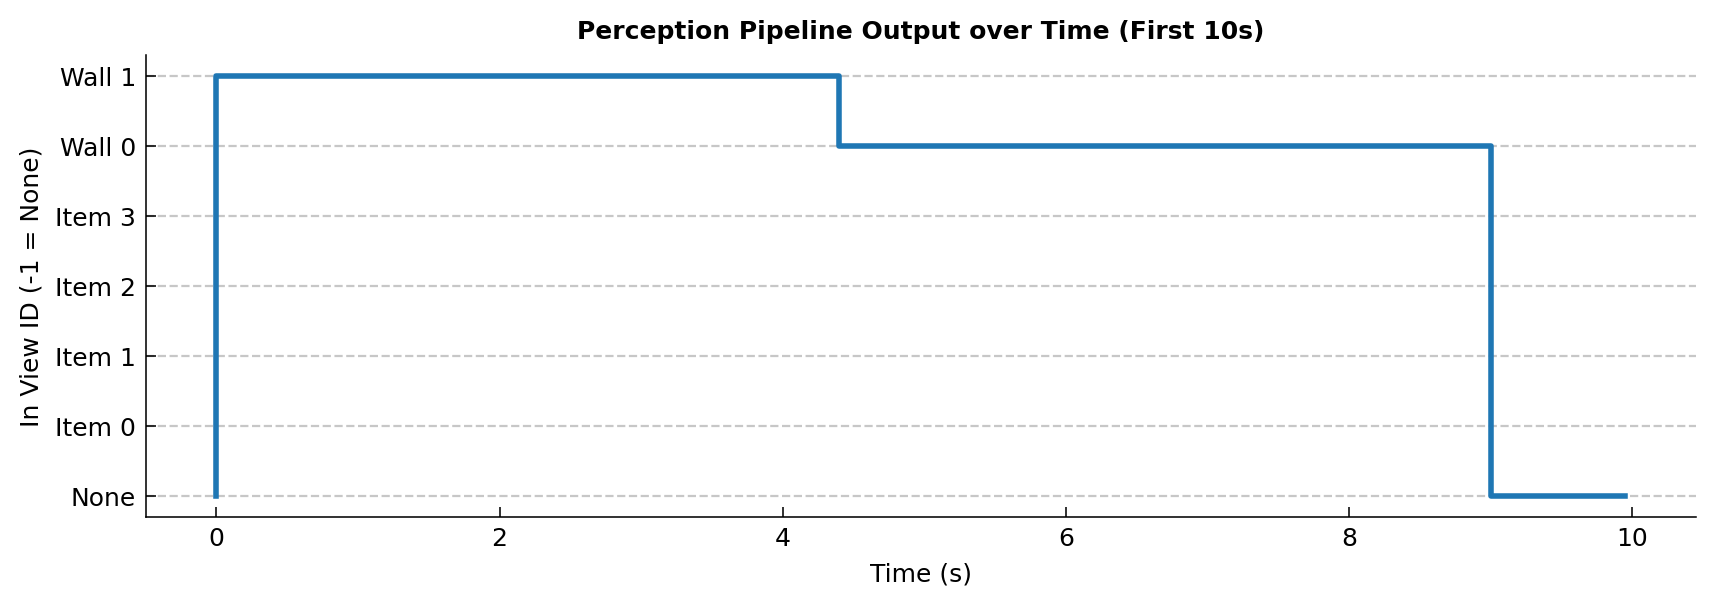

In [5]:
visible_ids = []
timeline = []

# Subsample time for faster test: every 50ms instead of 1ms
test_dt = 0.05
test_times = np.arange(0, 10, test_dt)  # Test the first 10 seconds

for t in test_times:
    vis_id = landmark_id_func(t)
    visible_ids.append(vis_id)
    timeline.append(t)

# Visualizing what the agent sees over time
plt.figure(figsize=(10, 3))
plt.plot(timeline, visible_ids, drawstyle="steps-pre", linewidth=2)
plt.title("Perception Pipeline Output over Time (First 10s)")
plt.xlabel("Time (s)")
plt.ylabel("In View ID (-1 = None)")
plt.yticks(ticks=np.arange(-1, n_items + n_walls), 
           labels=["None"] + [f"Item {i}" for i in range(n_items)] + [f"Wall {i}" for i in range(n_walls)])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


# ## 5. Visualizing position alongside perception
# 




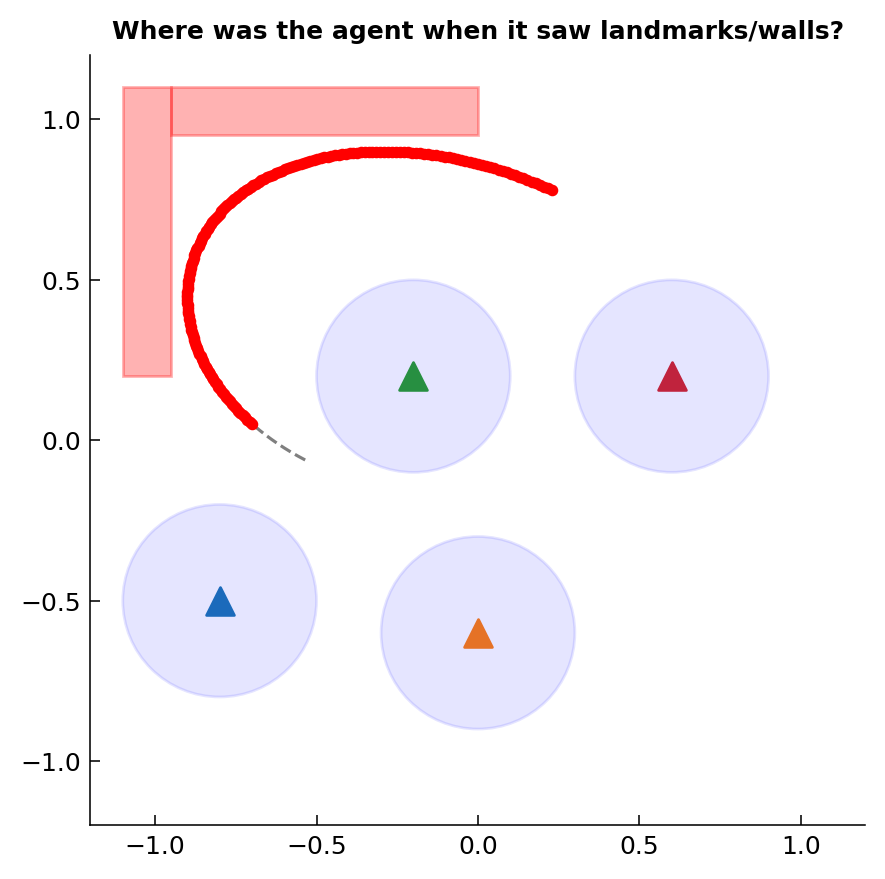

In [6]:
# Let's plot the agent's path in 2D and highlight where it was when it perceived specific items.
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(path[:int(10/dt), 0], path[:int(10/dt), 1], 'k--', alpha=0.5, label="Agent Path (0-10s)")

# Plot Items
for i, loc in enumerate(item_locations):
    ax.scatter(loc[0], loc[1], marker='^', s=100, label=f"Item {i}")
    circle = plt.Circle((loc[0], loc[1]), view_rad, color='b', alpha=0.1)
    ax.add_patch(circle)

# Plot Walls
for i, b in enumerate(wall_boundaries):
    ax.add_patch(Rectangle((b[0,0], b[1,0]), b[0,1]-b[0,0], b[1,1]-b[1,0], color='r', alpha=0.3, label=f"Wall {i}"))
    
# Plot points on the path where something was seen
for t, vis_id in zip(test_times, visible_ids):
    if vis_id != -1:
        idx = int(t/dt)
        color = 'b' if vis_id < n_items else 'r'
        ax.scatter(path[idx, 0], path[idx, 1], color=color, s=10, zorder=5)

ax.set_title("Where was the agent when it saw landmarks/walls?")
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
plt.show()
